#### Bloque Ejemplo 1 – Plan agregado gráfico  Proveedor de materiales para tejados (Juárez, México)
####  Datos de entrada
#### Demanda mensual (enero–junio): [900, 700, 800, 1200, 1500, 1100]
#### Días laborables por mes: [22, 18, 21, 21, 22, 20]
#### Inventario inicial: 0
#### Inventario final deseado: 0
#### Capacidad media: 50 unidades/día (calculada como 6.200 ÷ 124 días).


           Mes  Demanda  Días  Demanda por día
0        Enero      900    22             41.0
1      Febrero      700    18             39.0
2        Marzo      800    21             38.0
3        Abril     1200    21             57.0
4         Mayo     1500    22             68.0
5        Junio     1100    20             55.0
Total    Total     6200   124              NaN


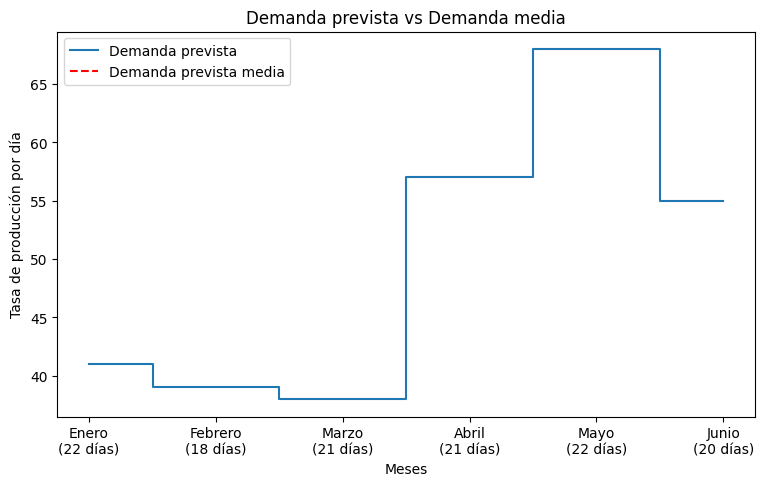

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math
from decimal import Decimal, ROUND_HALF_UP

def redondear_half_up(x, decimales=0):
    factor = Decimal('1.' + '0'*decimales)
    return float(Decimal(str(x)).quantize(factor, rounding=ROUND_HALF_UP))


def ejemplo1_plan_agregado(demanda, dias_mes, empleados, horas_por_unidad, costos):
    """
    Ejemplo 1: Presentación gráfica de un plan agregado.
    Incluye columna de demanda calculada por día y totales al final.
    """
    produccion_diaria = (8 / horas_por_unidad) * empleados
    resultados = []

    # Lista de nombres de meses
    meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"]

    inventario = 0
    for mes_nombre, (d, dias) in zip(meses, zip(demanda, dias_mes)):
        produccion_mes = produccion_diaria * dias
        inventario = inventario + produccion_mes - d
        demanda_por_dia = d / dias
        resultados.append({
            "Mes": mes_nombre,
            "Demanda": d,
            "Días": dias,
            "Demanda por día": redondear_half_up(demanda_por_dia, 0),
          
        })

         
    df = pd.DataFrame(resultados)

    # Agregar fila de totales
    total_demanda = sum(demanda)
    total_dias = sum(dias_mes)
    df.loc["Total"] = {
        "Mes": "Total",
        "Demanda": total_demanda,
        "Días": total_dias,
       "Demanda por día": ""   # vacío 

    }

    return df

def graficar_ejemplo1(df):
    """
    Grafica la demanda prevista por día y la demanda media.
    """
    plt.figure(figsize=(9,5))
    # Excluir la fila de totales para el gráfico
    df_plot = df.drop("Total")
    plt.step(df_plot["Mes"], df_plot["Demanda por día"], where="mid", label="Demanda prevista")
    plt.axhline(y=df.loc["Total","Demanda por día"], color="red", linestyle="--", label="Demanda prevista media")
    # Etiquetas con meses y días
    plt.xticks(df_plot["Mes"], [f"{m}\n({d} días)" for m, d in zip(df_plot["Mes"], df_plot["Días"])])
    plt.xlabel("Meses")
    plt.ylabel("Tasa de producción por día")
    plt.title("Demanda prevista vs Demanda media")
    plt.legend()
    plt.show()

# Datos del Ejemplo 1
demanda = [900, 700, 800, 1200, 1500, 1100]
dias_mes = [22, 18, 21, 21, 22, 20]
costos = {"inventario": 5, "salario": 40}

# Caso con 10 empleados
df_plan = ejemplo1_plan_agregado(demanda, dias_mes, empleados=10, horas_por_unidad=1.6, costos=costos)

print(df_plan)

graficar_ejemplo1(df_plan)


####  Ejemplo 2 – Plan 1: plantilla constante
#### Costos relevantes (TABLA 3.3):
#### Almacenamiento: 5 $/unidad/mes.
#### Subcontratación: 10 $/unidad.
#### Salario medio: 5 $/hora (40 $/día).
#### Hora extra: 7 $/hora (>8 horas/día).
#### Mano de obra: 1.6 horas/unidad.
#### Contratación: 300 $/unidad/día adicional.
#### Despido: 600 $/unidad/día reducida


In [2]:
import pandas as pd


def plan1_constante(demanda, dias_mes, costos):
    empleados = 10
    produccion_diaria = 50
    resultados = []
    inventario = 0
    inventario_total = 0

    meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"]

    for mes_nombre, d, dias in zip(meses, demanda, dias_mes):
        produccion_mes = produccion_diaria * dias
        valoracion = produccion_mes - d
        inventario = inventario + valoracion
        inventario_total += max(0, inventario)

        valoracion_str = f"+{valoracion}" if valoracion >= 0 else f"{valoracion}"

        resultados.append(
            {
                "Mes": mes_nombre,
                "Producción a 50 unidades/día": f"{produccion_mes:,}".replace(
                    ",", "."
                ),
                "Demanda estimada": f"{d:,}".replace(",", "."),
                "Valoración mensual del inventario": valoracion_str,
                "Inventario final": inventario,
            }
        )

    df = pd.DataFrame(resultados)
    fila_total = pd.DataFrame(
        [
            {
                "Mes": "Total",
                "Producción a 50 unidades/día": "",
                "Demanda estimada": "",
                "Valoración mensual del inventario": "",
                "Inventario final": f"{inventario_total:,}".replace(",", "."),
            }
        ]
    )
    df_final = pd.concat([df, fila_total], ignore_index=True)

    # ==========================================
    # CÁLCULO Y FORMATEO DE LA TABLA DE COSTES
    # ==========================================
    coste_inventario = inventario_total * costos["inventario"]
    coste_mano_obra = empleados * costos["salario"] * sum(dias_mes)
    coste_total = coste_inventario + coste_mano_obra

    # Formateo de strings numéricos con puntos de miles para los cálculos explicativos
    inv_total_fmt = f"{inventario_total:,}".replace(",", ".")
    dias_totales_fmt = f"{sum(dias_mes):,}".replace(",", ".")

    c_inv_fmt = f"{coste_inventario:,}".replace(",", ".")
    c_mo_fmt = f"{coste_mano_obra:,}".replace(",", ".")
    c_tot_fmt = f"{coste_total:,}".replace(",", ".")

    tabla_costes = pd.DataFrame(
        [
            {
                "Costes": f"Inventario {c_inv_fmt}$",
                "Cálculos": f"(= {inv_total_fmt} unidades almacenadas x {costos['inventario']}$/unidad)",
            },
            {
                "Costes": f"Mano de obra en periodo regular {c_mo_fmt}$",
                "Cálculos": f"(= {empleados} empleados x {costos['salario']}$/día x {dias_totales_fmt} días)",
            },
            {
                "Costes": "Otros costes (horas extras, contratación, despidos, subcontratación) 0$",
                "Cálculos": "",
            },
            {"Costes": f"Coste total {c_tot_fmt}$", "Cálculos": ""},
        ]
    )

    return df_final, tabla_costes


# Datos maestros extraídos de las imágenes
demanda_imagen = [900, 700, 800, 1200, 1500, 1100]
dias_mes_imagen = [22, 18, 21, 21, 22, 20]
costos = {"inventario": 5, "salario": 40}

# Ejecución del algoritmo
df_produccion, df_costes = plan1_constante(
    demanda_imagen, dias_mes_imagen, costos=costos
)

print("\n=== TABLA DE PRODUCCIÓN VS DEMANDA ===")
print(df_produccion.to_string(index=False))

print("\n=== TABLA DE COSTES ===")
print(df_costes.to_string(index=False))



=== TABLA DE PRODUCCIÓN VS DEMANDA ===
    Mes Producción a 50 unidades/día Demanda estimada Valoración mensual del inventario Inventario final
  Enero                        1.100              900                              +200              200
Febrero                          900              700                              +200              400
  Marzo                        1.050              800                              +250              650
  Abril                        1.050            1.200                              -150              500
   Mayo                        1.100            1.500                              -400              100
  Junio                        1.000            1.100                              -100                0
  Total                                                                                            1.850

=== TABLA DE COSTES ===
                                                                 Costes                        


=== TABLA DE PRODUCCIÓN VS DEMANDA ===
    Mes Producción a 50 unidades/día Demanda estimada Valoración mensual del inventario Inventario final
  Enero                        1.100              900                              +200              200
Febrero                          900              700                              +200              400
  Marzo                        1.050              800                              +250              650
  Abril                        1.050            1.200                              -150              500
   Mayo                        1.100            1.500                              -400              100
  Junio                        1.000            1.100                              -100                0
  Total                                                                                            1.850

=== TABLA DE COSTES ===
                                                                 Costes                        

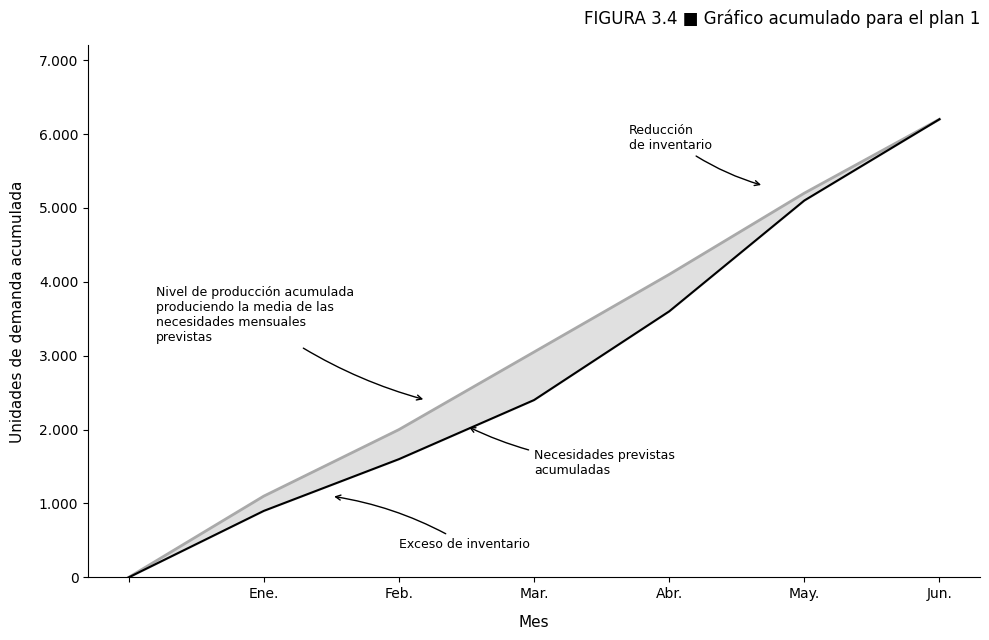

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plan1_constante(demanda, dias_mes, costos):
    empleados = 10
    produccion_diaria = 50
    resultados = []
    inventario = 0
    inventario_total = 0

    meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"]

    # Listas para almacenar las curvas acumuladas del gráfico
    prod_acumulada = [0]
    demanda_acumulada = [0]

    for d, dias in zip(demanda, dias_mes):
        produccion_mes = produccion_diaria * dias
        valoracion = produccion_mes - d
        inventario = inventario + valoracion
        inventario_total += max(0, inventario)

        # Rellenar datos acumulados dinámicos (empezando en cero)
        prod_acumulada.append(prod_acumulada[-1] + produccion_mes)
        demanda_acumulada.append(demanda_acumulada[-1] + d)

        valoracion_str = f"+{valoracion}" if valoracion >= 0 else f"{valoracion}"

        resultados.append(
            {
                "Mes": meses[len(resultados)],
                "Producción a 50 unidades/día": f"{produccion_mes:,}".replace(
                    ",", "."
                ),
                "Demanda estimada": f"{d:,}".replace(",", "."),
                "Valoración mensual del inventario": valoracion_str,
                "Inventario final": inventario,
            }
        )

    df = pd.DataFrame(resultados)
    fila_total = pd.DataFrame(
        [
            {
                "Mes": "Total",
                "Producción a 50 unidades/día": "",
                "Demanda estimada": "",
                "Valoración mensual del inventario": "",
                "Inventario final": f"{inventario_total:,}".replace(",", "."),
            }
        ]
    )
    df_final = pd.concat([df, fila_total], ignore_index=True)

    # Costes
    coste_inventario = inventario_total * costos["inventario"]
    coste_mano_obra = empleados * costos["salario"] * sum(dias_mes)
    coste_total = coste_inventario + coste_mano_obra

    tabla_costes = pd.DataFrame(
        [
            {
                "Costes": f"Inventario {coste_inventario:,}$".replace(",", "."),
                "Cálculos": f"(= {inventario_total:,} unidades almacenadas x {costos['inventario']}$/unidad)".replace(
                    ",", "."
                ),
            },
            {
                "Costes": f"Mano de obra en periodo regular {coste_mano_obra:,}$".replace(
                    ",", "."
                ),
                "Cálculos": f"(= {empleados} empleados x {costos['salario']}$/día x {sum(dias_mes):,} días)".replace(
                    ",", "."
                ),
            },
            {
                "Costes": "Otros costes (horas extras, contratación, despidos, subcontratación) 0$",
                "Cálculos": "",
            },
            {
                "Costes": f"Coste total {coste_total:,}$".replace(",", "."),
                "Cálculos": "",
            },
        ]
    )

    return df_final, tabla_costes, prod_acumulada, demanda_acumulada


def generar_grafico_acumulado(prod_acum, dem_acum):
    # Configurar dimensiones y estilo limpio
    plt.figure(figsize=(10, 6.5))
    x = np.arange(len(prod_acum))  # 0 a 6 (Inicio, Ene, Feb, Mar, Abr, May, Jun)

    # Dibujar las líneas de producción y demanda acumulada
    plt.plot(
        x,
        prod_acum,
        label="Nivel de producción acumulada",
        color="darkgray",
        linewidth=2,
    )
    plt.plot(
        x,
        dem_acum,
        label="Necesidades previstas acumuladas",
        color="black",
        linewidth=1.5,
    )

    # Rellenar el área intermedia (inventario/exceso y reducción) de gris como en la imagen
    plt.fill_between(
        x, prod_acum, dem_acum, color="#D3D3D3", alpha=0.7, label="Inventario"
    )

    # Configuración de ejes idéntica a la imagen
    plt.ylabel("Unidades de demanda acumulada", fontsize=11, labelpad=10)
    plt.xlabel("Mes", fontsize=11, labelpad=10)

    # Etiquetas del eje X desplazadas para simular el intervalo mensual de la imagen
    etiquetas_x = ["", "Ene.", "Feb.", "Mar.", "Abr.", "May.", "Jun."]
    plt.xticks(x, etiquetas_x)

    # Formatear eje Y con separador de miles por puntos
    plt.gca().get_yaxis().set_major_formatter(
        plt.FuncFormatter(lambda val, loc: f"{int(val):,}".replace(",", "."))
    )
    plt.ylim(0, 7200)

    # Quitar bordes superior y derecho para aspecto limpio de libro de texto
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)

    # =========================================================================
    # ANOTACIONES CON FLECHAS (IDÉNTICAS A LA FIGURA 3.4)
    # =========================================================================

    # Flecha 1: Nivel de producción acumulada...
    plt.annotate(
        "Nivel de producción acumulada\nproduciendo la media de las\nnecesidades mensuales\nprevistas",
        xy=(2.2, 2400),
        xytext=(0.2, 3200),
        arrowprops=dict(
            arrowstyle="->", connectionstyle="arc3,rad=0.1", color="black"
        ),
        fontsize=9,
    )

    # Flecha 2: Necesidades previstas acumuladas
    plt.annotate(
        "Necesidades previstas\nacumuladas",
        xy=(2.5, 2050),
        xytext=(3.0, 1400),
        arrowprops=dict(
            arrowstyle="->", connectionstyle="arc3,rad=-0.1", color="black"
        ),
        fontsize=9,
    )

    # Flecha 3: Exceso de inventario
    plt.annotate(
        "Exceso de inventario",
        xy=(1.5, 1100),
        xytext=(2.0, 400),
        arrowprops=dict(
            arrowstyle="->", connectionstyle="arc3,rad=0.1", color="black"
        ),
        fontsize=9,
    )

    # Flecha 4: Reducción de inventario
    plt.annotate(
        "Reducción\nde inventario",
        xy=(4.7, 5300),
        xytext=(3.7, 5800),
        arrowprops=dict(
            arrowstyle="->", connectionstyle="arc3,rad=0.1", color="black"
        ),
        fontsize=9,
    )

    plt.title("FIGURA 3.4 ■ Gráfico acumulado para el plan 1", loc="right", pad=15)
    plt.tight_layout()
    plt.show()
# Datos e inicialización
demanda_imagen = [900, 700, 800, 1200, 1500, 1100]
dias_mes_imagen = [22, 18, 21, 21, 22, 20]
costos = {"inventario": 5, "salario": 40}

# Ejecución
df_prod, df_cos, prod_ac, dem_ac = plan1_constante(
    demanda_imagen, dias_mes_imagen, costos
)

print("\n=== TABLA DE PRODUCCIÓN VS DEMANDA ===")
print(df_prod.to_string(index=False))

print("\n=== TABLA DE COSTES ===")
print(df_cos.to_string(index=False))

# Lanzar ventana con el gráfico matemático anotado
generar_grafico_acumulado(prod_ac, dem_ac)



#### Bloque – Ejemplo 3 (Plan 2: Subcontratistas + plantilla constante)

In [6]:
# Bloque: Ejemplo 3 - Plan 2 (Subcontratistas con plantilla constante)

import pandas as pd

def plan_subcontratistas(unidades_demanda, empleados, prod_diaria, dias_totales,
                         coste_diario_empleado, coste_subcontratacion):
    """
    Calcula producción propia, subcontratada y costes totales.
    
    unidades_demanda: demanda total en unidades
    empleados: número de empleados fijos
    prod_diaria: unidades producidas por día por empleado
    dias_totales: días de producción
    coste_diario_empleado: $/día por empleado
    coste_subcontratacion: $/unidad subcontratada
    """
    
    # Producción propia
    produccion_propia = prod_diaria * dias_totales
    
    # Unidades subcontratadas
    subcontratadas = max(0, unidades_demanda - produccion_propia)
    
    # Costes
    coste_mano_obra = empleados * coste_diario_empleado * dias_totales
    coste_subcontrat = subcontratadas * coste_subcontratacion
    coste_total = coste_mano_obra + coste_subcontrat
    
    # Tabla resumen
    df = pd.DataFrame({
        "Concepto": ["Producción propia", "Unidades subcontratadas", 
                     "Coste mano de obra", "Coste subcontratación", "Coste total"],
        "Valor": [produccion_propia, subcontratadas, 
                  coste_mano_obra, coste_subcontrat, coste_total]
    })
    
    return df

# Ejemplo con los datos del caso
df_plan2 = plan_subcontratistas(
    unidades_demanda=6200,
    empleados=7.6,
    prod_diaria=38,
    dias_totales=124,
    coste_diario_empleado=40,
    coste_subcontratacion=10
)

df_plan2


,Concepto,Valor
0,Producción propia,4712.0
1,Unidades subcontratadas,1488.0
2,Coste mano de obra,37696.0
3,Coste subcontratación,14880.0
4,Coste total,52576.0


##### Bloque – Ejemplo 4 (Plan 3: Contratación y despidos)

In [9]:
import pandas as pd

def plan_contratacion_despidos_tabla(demanda_mensual, tasa_diaria_inicial,
                                     horas_por_unidad=1.6, coste_hora=5,
                                     coste_contratacion=300, coste_despido=600,
                                     dias_mes=22):
    """
    Genera tabla con formato de la TABLA 3.4 y nombres de meses.
    """
    resultados = []
    tasa_anterior = tasa_diaria_inicial
    
    # Lista de meses (enero-junio)
    meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"]
    
    for i, demanda in enumerate(demanda_mensual):
        # Tasa diaria de producción ajustada
        tasa_diaria = round(demanda / dias_mes)
        
        # Coste básico
        coste_basico = demanda * horas_por_unidad * coste_hora
        
        # Ajustes contratación/despido
        coste_contratacion_mes = 0
        coste_despido_mes = 0
        
        if tasa_diaria > tasa_anterior:
            coste_contratacion_mes = (tasa_diaria - tasa_anterior) * coste_contratacion
        elif tasa_diaria < tasa_anterior:
            coste_despido_mes = (tasa_anterior - tasa_diaria) * coste_despido
        
        coste_total = coste_basico + coste_contratacion_mes + coste_despido_mes
        
        resultados.append({
            "Mes": meses[i],
            "Previsión (unidades)": demanda,
            "Tasa de producción diaria": tasa_diaria,
            "Coste producción básica": coste_basico,
            "Coste contratación": coste_contratacion_mes if coste_contratacion_mes > 0 else "—",
            "Coste despido": coste_despido_mes if coste_despido_mes > 0 else "—",
            "Coste total": coste_total
        })
        
        tasa_anterior = tasa_diaria
    
    df = pd.DataFrame(resultados)
    
    # Totales al pie
    totales = {
        "Mes": "Totales",
        "Previsión (unidades)": "—",
        "Tasa de producción diaria": "—",
        "Coste producción básica": df["Coste producción básica"].sum(),
        "Coste contratación": sum(x if isinstance(x,(int,float)) else 0 for x in df["Coste contratación"]),
        "Coste despido": sum(x if isinstance(x,(int,float)) else 0 for x in df["Coste despido"]),
        "Coste total": df["Coste total"].sum()
    }
    df = pd.concat([df, pd.DataFrame([totales])], ignore_index=True)
    
    return df

# Ejemplo con datos del caso
demanda = [900, 700, 800, 1200, 1500, 1100]
df_plan3_tabla = plan_contratacion_despidos_tabla(demanda, tasa_diaria_inicial=41)
df_plan3_tabla


,Mes,Previsión (unidades),Tasa de producción diaria,Coste producción básica,Coste contratación,Coste despido,Coste total
0,Enero,900,41,7200.0,—,—,7200.0
1,Febrero,700,32,5600.0,—,5400,11000.0
2,Marzo,800,36,6400.0,1200,—,7600.0
3,Abril,1200,55,9600.0,5700,—,15300.0
4,Mayo,1500,68,12000.0,3900,—,15900.0
5,Junio,1100,50,8800.0,—,10800,19600.0
6,Totales,—,—,49600.0,10800,16200,76600.0
